![](Images/banner_health_analytics.png){fig-align="center" width="100%"}


### Module 07: Geospatial & Spatial Epidemiology


# Geostatistical Risk Analysis



**Learning objectives**
- Understand indicator kriging (IK) for probabilistic geostatistical risk mapping
- Prepare groundwater arsenic survey data with detection-limit censoring rules
- Transform continuous concentrations into binary health-risk indicators (WHO & Bangladesh thresholds)
- Compute, model, and visualise indicator semivariograms
- Validate IK predictions with k-fold cross-validation
- Map the probability of exceeding regulatory arsenic limits across Bangladesh
- Interpret IK outputs for environmental health decision-making

**Data:** `Data/bgs_geochemical.csv`, `Data/bd_grid.csv`, `Data/BD_Banladesh_BUTM.shp` (+ sidecar files)  
**Context:** British Geological Survey (BGS) groundwater survey, 3,534 boreholes across 61 districts  
**Thresholds:** 10 µg/L (WHO) and 50 µg/L (Bangladesh national standard)  
**Estimated time:** 3 hours | **Level:** Advanced  
**Libraries:** `geopandas`, `numpy`, `pandas`, `scipy`, `matplotlib` (indicator kriging via the custom `pygstat` module: `fit_indicator_variogram` + `IndicatorKriging`)


## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from scipy.optimize import curve_fit

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
})

DATA = Path("Data")
THRESHOLDS = {"WHO": 10, "Bangladesh": 50}  # µg/L (ppb)
print("Setup complete")


Setup complete


## 2. Indicator Kriging for Environmental Health Risk

**Kriging** is a geostatistical interpolation technique that provides the *best linear unbiased prediction* (BLUP) of a spatially distributed variable, based on observed data and a model of spatial autocorrelation (the variogram). For a location $\mathbf{s}_0$, the ordinary kriging estimate $\hat{Z}(\mathbf{s}_0)$ is a weighted sum of $n$ observed values:

$$
\hat{Z}(\mathbf{s}_0) = \sum_{i=1}^n \lambda_i Z(\mathbf{s}_i)
$$

where $Z(\mathbf{s}_i)$ are the observed values at known locations $\mathbf{s}_i$, and $\lambda_i$ are weights optimized to minimize prediction variance, subject to unbiasedness (weights sum to 1).

**Indicator kriging (IK)** extends this approach for modeling the *probability* that a variable exceeds a threshold $z_c$, rather than its absolute value. Instead of direct values, we code:

$$
I(\mathbf{s}_i; z_c) = 
  \begin{cases}
    1 & \text{if } Z(\mathbf{s}_i) > z_c \\
    0 & \text{otherwise}
  \end{cases}
$$

and perform ordinary kriging on $I(\mathbf{s}_i; z_c)$ to estimate, at each unsampled location $\mathbf{s}_0$, the *conditional probability*:

$$
\mathbb{P}[Z(\mathbf{s}_0) > z_c \mid \text{data}] \approx \hat{I}(\mathbf{s}_0; z_c) = \sum_{i=1}^n \lambda_i I(\mathbf{s}_i; z_c)
$$

Thus, indicator kriging yields a spatial probability surface, mapping the risk of exceeding health-relevant thresholds.

This is directly useful for probabilistic decision-making in environmental epidemiology:

| Application | Why IK helps |
|-------------|-------------|
| **Regulatory compliance** | Map P(As > 10 µg/L) for WHO guideline exceedance |
| **National standards** | Map P(As > 50 µg/L) for Bangladesh drinking-water policy |
| **Skewed distributions** | Arsenic is strongly right-skewed; log-transforms distort tail behaviour |
| **Censored data** | Detection-limit samples can be handled before indicator coding |

IK can also estimate an entire cumulative distribution function (CDF); the mean of the CDF (E-type estimate) provides a concentration estimate when multiple thresholds are modelled [(Goovaerts, 2009)](https://www.ncbi.nlm.nih.gov/pubmed/20161335).

In this notebook we follow the classic BGS Bangladesh arsenic workflow:

1. Convert arsenic concentrations to indicator variables at 10 and 50 µg/L
2. Compute and model indicator semivariograms
3. Predict the probability of exceeding each threshold by indicator kriging
4. Visualise probability surfaces on a national prediction grid


## 3. Load Data

In [2]:
df = pd.read_csv(DATA / "bgs_geochemical.csv")
grid = pd.read_csv(DATA / "bd_grid.csv")
bd = gpd.read_file(DATA / "BD_Banladesh_BUTM.shp")

print(f"BGS samples : {len(df):,} boreholes")
print(f"Prediction grid: {len(grid):,} cells")
print(f"Bangladesh boundary CRS: {bd.crs}")
print(f"Districts in shapefile: {len(bd)}")
df.head(3)


BGS samples : 3,534 boreholes
Prediction grid: 5,339 cells
Bangladesh boundary CRS: PROJCS["Bangladesh Universal Tranverse Mercator (BUTM_2010)",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",90],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Districts in shapefile: 369


,SAMPLE_ID,SAMPLE_FIELD_ID,SAMPLE_DATE,LONG_DEG,LAT_DEG,YEAR_CONSTRUCTION,WELL_TYPE,WELL_DEPTH,DIVISION,DISTRICT,...,Li,Mg,Mn,Na,P_,Si,SO4,Sr,V_,Zn
0,S98_02701,RIP1640,9/5/1998,90.093,22.372,1993.0,DTW,322.0,Barisal,Jhalakati,...,0.015,52.8,0.182,1690.0,2.6,7.85,< 0.2,1.52,< 0.006,0.028
1,S98_02715,RIP2184,16/04/1998,89.410,23.942,1977.0,STW,42.0,Rajshahi,Pabna,...,0.003,36.6,1.79,52.4,0.4,19.9,< 0.2,0.424,0.007,0.017
2,S98_02979,RIP0490,2/6/1998,91.603,24.572,1995.0,STW,38.0,Sylhet,Habiganj,...,< 0.003,6.59,0.146,60.4,0.3,20.8,< 0.2,0.159,< 0.006,< 0.008


### 3.1 Handle detection limits

About 27.7% of wells had arsenic below the instrumental detection limit of 0.5 µg/L. Following the BGS protocol, censored values are assigned **half the detection limit** (0.25 µg/L) before analysis.


In [3]:
def parse_concentration(val, dl=0.5, half_dl=0.25):
    """Parse numeric or censored (< DL) geochemical values."""
    if isinstance(val, str):
        s = val.strip()
        if s.startswith("<"):
            return half_dl
        try:
            val = float(s)
        except ValueError:
            return np.nan
    if np.isclose(val, dl):
        return half_dl  # BGS: below DL reported as 0.5 -> impute 0.25
    return float(val)

df["As_ppb"] = df["As"].apply(parse_concentration)
n_at_dl = (pd.to_numeric(df["As"], errors="coerce") == 0.5).sum()
n_censored = df["As"].astype(str).str.strip().str.startswith("<").sum()
print(f"Values at detection limit (0.5 -> 0.25 µg/L): {n_at_dl:,} ({100*n_at_dl/len(df):.1f}%)")
print(f"Censored string readings (< DL): {n_censored:,}")
print(df["As_ppb"].describe().round(2))


Values at detection limit (0.5 -> 0.25 µg/L): 33 (0.9%)
Censored string readings (< DL): 0
count    3534.00
mean       55.17
std       118.51
min         0.25
25%         0.25
50%         3.90
75%        49.98
max      1660.00
Name: As_ppb, dtype: float64


## 4. Exploratory Data Analysis

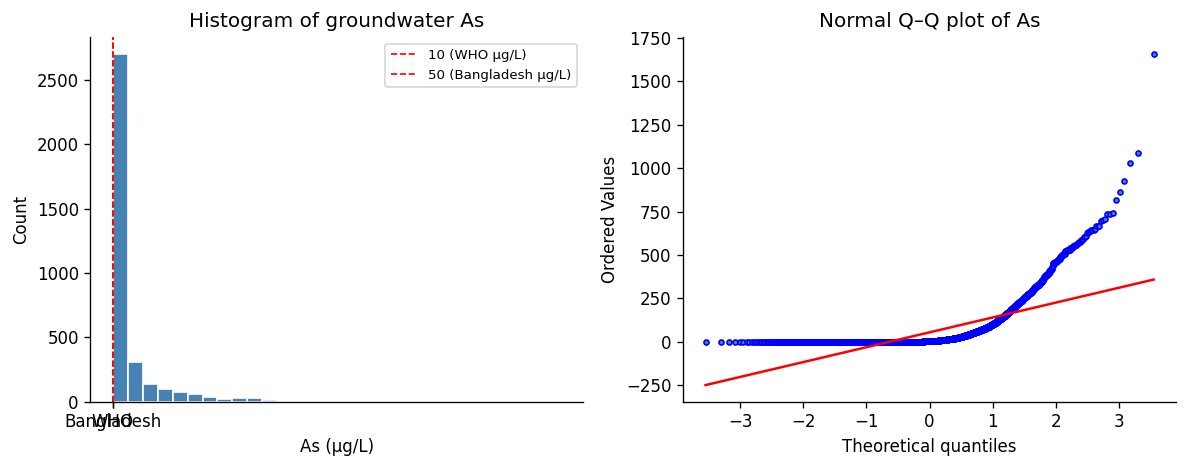

Samples exceeding WHO standard (10 µg/L): 42.1%
Samples exceeding Bangladesh standard (50 µg/L): 24.9%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df["As_ppb"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_xlabel("As (µg/L)")
axes[0].set_ylabel("Count")
axes[0].set_title("Histogram of groundwater As")
for thr, label in THRESHOLDS.items():
    axes[0].axvline(thr, color="red", ls="--", lw=1, label=f"{label} ({thr} µg/L)")
axes[0].legend(fontsize=8)

stats.probplot(df["As_ppb"].dropna(), dist="norm", plot=axes[1])
axes[1].set_title("Normal Q–Q plot of As")
axes[1].get_lines()[0].set_markerfacecolor("steelblue")
axes[1].get_lines()[0].set_markersize(3)
plt.tight_layout()
plt.show()

for name, thr in THRESHOLDS.items():
    pct = 100 * (df["As_ppb"] > thr).mean()
    print(f"Samples exceeding {name} standard ({thr} µg/L): {pct:.1f}%")


## 5. Project Sample Locations to BUTM

Sample coordinates are stored as longitude/latitude (WGS 84). We reproject borehole locations to **Bangladesh Universal Transverse Mercator (BUTM)**, the same projected CRS as the national boundary shapefile,  so that Euclidean distances in metres are meaningful for the semivariogram.


In [5]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["LONG_DEG"], df["LAT_DEG"]),
    crs="EPSG:4326",
)
gdf_proj = gdf.to_crs(bd.crs)

mf = pd.DataFrame({
    "x": gdf_proj.geometry.x.astype(float),
    "y": gdf_proj.geometry.y.astype(float),
    "As": df["As_ppb"].values,
    "DISTRICT": df["DISTRICT"].values,
}).dropna(subset=["As"])

n_before = len(mf)
mf = mf.drop_duplicates(subset=["x", "y"])
print(f"Unique sample locations: {len(mf):,} (dropped {n_before - len(mf)} duplicates)")
mf.head()


Unique sample locations: 3,420 (dropped 114 duplicates)


,x,y,As,DISTRICT
0,509574.303617,2.474006e+06,0.25,Jhalakati
1,439962.885256,2.647931e+06,0.25,Pabna
2,662328.060675,2.718502e+06,0.25,Habiganj
3,619708.426742,2.631583e+06,0.25,Brahamanbaria
4,454332.152111,2.522667e+06,0.25,Khulna


## 6. Indicator Transformation

In [6]:
for name, thr in THRESHOLDS.items():
    col = f"ik_{thr}"
    mf[col] = (mf["As"] > thr).astype(float)
    print(f"ik_{thr} (As > {thr} µg/L): mean = {mf[col].mean():.3f} "
          f"({mf[col].sum():.0f} / {len(mf)} samples above threshold)")
mf[["x", "y", "As", "ik_10", "ik_50"]].head()


ik_10 (As > 10 µg/L): mean = 0.414 (1415 / 3420 samples above threshold)
ik_50 (As > 50 µg/L): mean = 0.244 (834 / 3420 samples above threshold)


,x,y,As,ik_10,ik_50
0,509574.303617,2.474006e+06,0.25,0.0,0.0
1,439962.885256,2.647931e+06,0.25,0.0,0.0
2,662328.060675,2.718502e+06,0.25,0.0,0.0
3,619708.426742,2.631583e+06,0.25,0.0,0.0
4,454332.152111,2.522667e+06,0.25,0.0,0.0


## 7. Map Sample Data

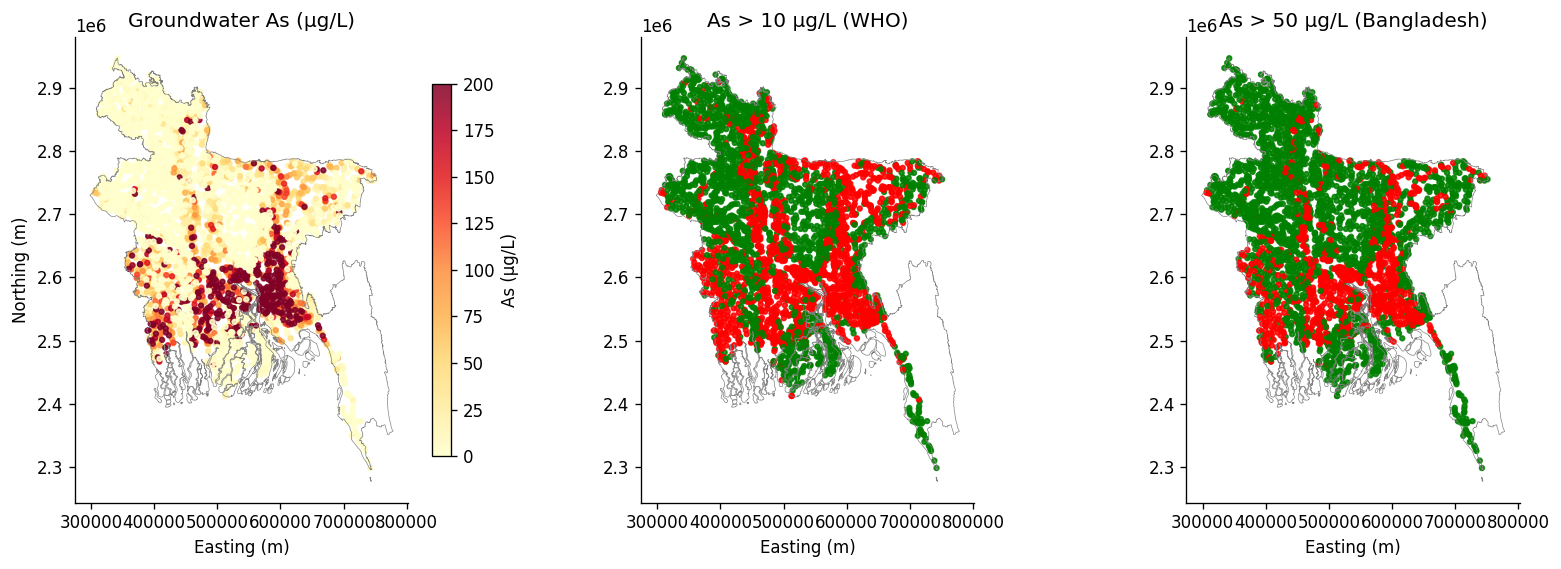

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
bd.boundary.plot(ax=axes[0], color="grey", linewidth=0.4)
sc0 = axes[0].scatter(mf.x, mf.y, c=mf.As, s=8, cmap="YlOrRd", vmin=0, vmax=200, alpha=0.85)
plt.colorbar(sc0, ax=axes[0], label="As (µg/L)", shrink=0.8)
axes[0].set_title("Groundwater As (µg/L)")
axes[0].set_xlabel("Easting (m)"); axes[0].set_ylabel("Northing (m)")

for ax, col, title in zip(axes[1:], ["ik_10", "ik_50"],
                          ["As > 10 µg/L (WHO)", "As > 50 µg/L (Bangladesh)"]):
    bd.boundary.plot(ax=ax, color="grey", linewidth=0.4)
    colors = np.where(mf[col] == 1, "red", "green")
    ax.scatter(mf.x, mf.y, c=colors, s=8, alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel("Easting (m)")
plt.tight_layout()
plt.show()


## 8. Indicator Semivariograms

**What is a variogram?**  
In geostatistics, the (semi)variogram quantifies how spatial similarity between observations decreases as the distance between them increases. For a spatial variable $Z(\mathbf{s})$, the *semivariogram* at a given lag distance $h$ is mathematically defined as:

$$
\gamma(h) = \frac{1}{2N(h)} \sum_{i,j;\ |\mathbf{s}_i-\mathbf{s}_j| \approx h} [ Z(\mathbf{s}_i) - Z(\mathbf{s}_j) ]^2
$$

where $N(h)$ is the number of sample pairs separated by approximately $h$.

**What is an indicator variogram?**  
An *indicator variogram* applies the same principle, but to a binary (0/1) transformation of the variable. For example, for a threshold $T$, the indicator variable $I_T(\mathbf{s})$ is given by:

$$
I_T(\mathbf{s}) = 
   \begin{cases}
     1, & \text{if } Z(\mathbf{s}) > T \\\\
     0, & \text{otherwise}
   \end{cases}
$$

The indicator semivariogram is then:

$$
\gamma_{I_T}(h) = \frac{1}{2N(h)} \sum_{i,j;\ |\mathbf{s}_i-\mathbf{s}_j| \approx h} [ I_T(\mathbf{s}_i) - I_T(\mathbf{s}_j) ]^2
$$

Indicator variograms describe the spatial continuity of high/low risk zones (e.g., areas exceeding an arsenic threshold). In practice, we fit a model (e.g., exponential) to the experimental variogram points to estimate parameters such as nugget, sill, and range.

In this section we compute the **experimental** indicator variogram with `fit_indicator_variogram` (from the `pygstat` module), then fit a theoretical model (spherical **or** exponential, whichever gives the lower sum-of-squared error) by least squares. The fitted **nugget**, **partial sill** and **range** feed directly into the `IndicatorKriging` predictor in the next sections.

> **Note on convention.** `fit_indicator_variogram` codes the indicator as $I(Z \le t)$ while `IndicatorKriging` codes exceedance as $I(Z \ge t)$. The two indicators differ only by a constant, which the variogram removes — so the fitted structure is identical and transfers directly to the exceedance-probability maps.


In [8]:
# =====================================================================
# pygstat / indicator_variogram.py  (uploaded module, used as-is)
# Experimental indicator variogram.
# Convention: I(Z <= threshold). The indicator variogram is symmetric
# in the cutoff (I(Z<=t) and I(Z>=t) differ only by a constant, which
# the variogram removes), so the fitted nugget/sill/range apply
# directly to the exceedance indicator used by IndicatorKriging.
# =====================================================================
import numpy as np
from scipy.spatial.distance import pdist

def fit_indicator_variogram(coords, values, threshold, maxlag=None, n_lags=10):
    """
    Fit empirical indicator variogram and return lags, gamma.

    Indicator convention: I(Z <= threshold), i.e. 1 if value <= threshold else 0.
    For P(Z >= t) use IndicatorKriging with the same threshold; it uses I(Z >= t) internally.
    """
    coords = np.asarray(coords)
    values = np.asarray(values)

    if coords.ndim != 2:
        raise ValueError("coords must be a 2D array with shape (n_points, dim)")
    if values.ndim != 1 or values.shape[0] != coords.shape[0]:
        raise ValueError("values must be a 1D array with the same length as coords")

    # Create indicator variable: 1 if value <= threshold, else 0
    indicators = (values <= threshold).astype(float)

    # Pairwise distances between coordinates
    dists = pdist(coords)
    if dists.size == 0:
        return np.array([]), np.array([])

    # Default maxlag is half the maximum pairwise distance
    if maxlag is None:
        maxlag = dists.max() / 2.0

    # Define lag bins and their centers
    bin_edges = np.linspace(0.0, maxlag, n_lags + 1)
    lags = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Pairwise squared differences of indicators
    ind_diffs_sq = pdist(indicators[:, None], metric='euclidean') ** 2

    # Experimental semivariance per lag bin: 0.5 * mean squared difference
    experimental_gamma = np.full(n_lags, np.nan)
    for i in range(n_lags):
        mask = (dists >= bin_edges[i]) & (dists < bin_edges[i + 1])
        if np.any(mask):
            experimental_gamma[i] = 0.5 * np.mean(ind_diffs_sq[mask])

    return lags, experimental_gamma

print("fit_indicator_variogram loaded")


fit_indicator_variogram loaded


In [9]:
# =====================================================================
# pygstat / indicator_kriging.py  (uploaded module, used as-is)
# Ordinary indicator kriging with per-threshold variogram support.
# Convention: I(Z >= threshold) -> predict() returns P(Z >= threshold),
# i.e. the probability of EXCEEDING (being unsafe at) the cutoff.
# =====================================================================
import numpy as np
from scipy.spatial import cKDTree
from scipy.linalg import solve, LinAlgError
from typing import Union, List, Dict, Optional, Tuple

# ---- Covariance models C(h) ----
def _spherical_covariance(h, sill, rng, nugget=0.0):
    h = np.asarray(h, dtype=float)
    c = np.zeros_like(h)
    mask = h < rng
    hr = h[mask] / rng
    c[mask] = sill * (1.0 - 1.5 * hr + 0.5 * hr ** 3)
    c[h == 0] += nugget
    return c

def _exponential_covariance(h, sill, rng, nugget=0.0):
    h = np.asarray(h, dtype=float)
    c = sill * np.exp(-h / rng)
    c[h == 0] += nugget
    return c

_COV_MODELS = {'spherical': _spherical_covariance,
               'exponential': _exponential_covariance}

# ---- Helpers ----
def _indicator_transform(values, threshold):
    """Binary indicator I(Z >= threshold): 1 if value >= threshold else 0."""
    return (np.asarray(values) >= threshold).astype(float)

def _apply_anisotropy(coords, angle=0.0, ratio=1.0):
    if angle == 0.0 and ratio == 1.0:
        return coords, None
    theta = np.deg2rad(angle)
    rotation = np.array([[np.cos(theta), -np.sin(theta)],
                         [np.sin(theta),  np.cos(theta)]])
    inv_scale = np.diag([1.0 / ratio, 1.0])
    transform_matrix = inv_scale @ rotation.T
    return coords @ transform_matrix.T, transform_matrix

def _solve_ordinary_kriging_system(neighbor_coords, target, cov_model,
                                   sill, rng, nugget, regularization=1e-8):
    """Solve the ordinary kriging system with a Lagrange multiplier."""
    n = neighbor_coords.shape[0]
    if n == 0:
        raise ValueError("No neighbors found.")
    diff = neighbor_coords[:, None, :] - neighbor_coords[None, :, :]
    dists = np.sqrt(np.sum(diff ** 2, axis=2))
    K = np.zeros((n + 1, n + 1))
    K[:n, :n] = cov_model(dists, sill, rng, nugget)
    K[:n, n] = 1.0
    K[n, :n] = 1.0
    K[n, n] = 0.0
    if regularization > 0:
        K[:n, :n] += np.eye(n) * regularization
    d0 = np.sqrt(np.sum((neighbor_coords - target) ** 2, axis=1))
    rhs = np.zeros(n + 1)
    rhs[:n] = cov_model(d0, sill, rng, nugget)
    rhs[n] = 1.0
    try:
        solution = solve(K, rhs, assume_a="sym")
    except LinAlgError:
        solution = np.linalg.lstsq(K, rhs, rcond=None)[0]
    return solution[:n]

class IndicatorKriging:
    """Ordinary Indicator Kriging with per-threshold variogram support."""

    def __init__(self, cov_model='spherical', max_neighbors=12,
                 search_radius=None, anisotropy_angle=0.0,
                 anisotropy_ratio=1.0, regularization=1e-8):
        if cov_model not in _COV_MODELS:
            raise ValueError(f"cov_model must be one of {list(_COV_MODELS.keys())}")
        self.cov_model_name = cov_model
        self.cov_model = _COV_MODELS[cov_model]
        self.max_neighbors = max_neighbors
        self.search_radius = search_radius
        self.anisotropy_angle = anisotropy_angle
        self.anisotropy_ratio = anisotropy_ratio
        self.regularization = regularization
        self.is_fitted_ = False

    def fit(self, coords, values):
        """Store training data (coords in projected metres, continuous values)."""
        coords = np.asarray(coords)
        values = np.asarray(values)
        if coords.shape[0] != values.shape[0]:
            raise ValueError("coords and values must have the same length.")
        if coords.shape[1] != 2:
            raise ValueError("coords must be 2D (x, y).")
        self.coords_ = coords.copy()
        self.values_ = values.copy()
        self.coords_transformed_, self.transform_matrix_ = _apply_anisotropy(
            self.coords_, self.anisotropy_angle, self.anisotropy_ratio)
        self.tree_ = cKDTree(self.coords_transformed_)
        self.is_fitted_ = True
        return self

    def predict(self, coords_pred, thresholds, variogram_params=None):
        """
        Predict P(Z >= threshold) at coords_pred for each threshold.
        variogram_params : {threshold: (nugget, partial_sill, range)}
        Returns {threshold: probability_array}.
        """
        if not self.is_fitted_:
            raise RuntimeError("Model must be fitted before prediction.")
        coords_pred = np.asarray(coords_pred)
        if coords_pred.shape[1] != 2:
            raise ValueError("coords_pred must be 2D (x, y).")
        thresholds = np.atleast_1d(thresholds).tolist()
        probabilities = {}

        if variogram_params is None:
            max_dist = np.percentile(np.sqrt(np.sum(
                (self.coords_[:, None, :] - self.coords_[None, :, :]) ** 2, axis=2)), 50)
            default_params = (0.01, 0.25, max_dist * 0.6)
            variogram_params = {t: default_params for t in thresholds}

        if self.transform_matrix_ is not None:
            coords_pred_t = coords_pred @ self.transform_matrix_.T
        else:
            coords_pred_t = coords_pred.copy()

        for threshold in thresholds:
            if threshold not in variogram_params:
                raise KeyError(f"Variogram parameters missing for threshold {threshold}")
            nugget, sill, rng = variogram_params[threshold]
            indicator_train = _indicator_transform(self.values_, threshold)
            prob_pred = np.full(len(coords_pred), np.nan)

            for i, target_t in enumerate(coords_pred_t):
                if self.search_radius is not None:
                    neighbor_idxs = self.tree_.query_ball_point(target_t, r=self.search_radius)
                    if len(neighbor_idxs) == 0:
                        continue
                    if len(neighbor_idxs) > self.max_neighbors:
                        dd = np.linalg.norm(
                            self.coords_transformed_[neighbor_idxs] - target_t, axis=1)
                        neighbor_idxs = np.array(neighbor_idxs)[np.argsort(dd)[:self.max_neighbors]]
                else:
                    k = min(self.max_neighbors, len(self.coords_transformed_))
                    _, neighbor_idxs = self.tree_.query(target_t, k=k)
                    neighbor_idxs = [neighbor_idxs] if np.isscalar(neighbor_idxs) else neighbor_idxs
                try:
                    weights = _solve_ordinary_kriging_system(
                        self.coords_[neighbor_idxs], coords_pred[i],
                        self.cov_model, sill, rng, nugget, self.regularization)
                    prob_pred[i] = np.clip(np.dot(weights, indicator_train[neighbor_idxs]), 0.0, 1.0)
                except Exception:
                    prob_pred[i] = np.mean(indicator_train[neighbor_idxs])
            probabilities[threshold] = prob_pred
        return probabilities

print("IndicatorKriging loaded")


IndicatorKriging loaded


In [10]:
# ---------------------------------------------------------------
# Fit a theoretical model (spherical / exponential) to each
# empirical indicator variogram, then auto-select the better fit.
# The variogram model uses the SAME parametrisation as the
# covariance models inside IndicatorKriging, so (nugget, partial
# sill, range) transfer directly into ik.predict(variogram_params=).
# ---------------------------------------------------------------
def _spherical_vgm(h, nugget, psill, rng):
    h = np.asarray(h, float)
    g = np.where(h < rng, nugget + psill * (1.5 * (h / rng) - 0.5 * (h / rng) ** 3),
                 nugget + psill)
    return np.where(h == 0, 0.0, g)

def _exponential_vgm(h, nugget, psill, rng):
    h = np.asarray(h, float)
    return nugget + psill * (1.0 - np.exp(-h / rng))

_VGM_MODELS = {"spherical": _spherical_vgm, "exponential": _exponential_vgm}

def fit_variogram_model(lags, gamma, model):
    """Least-squares fit; returns ((nugget, partial_sill, range), SSE)."""
    ok = ~np.isnan(gamma)
    h, g = lags[ok], gamma[ok]
    gmax = float(np.nanmax(g))
    p0 = [0.0, gmax, h.max() / 3.0]
    bounds = ([0.0, 0.0, max(h.min(), 1.0)], [gmax * 1.5, gmax * 3.0, h.max() * 3.0])
    popt, _ = curve_fit(_VGM_MODELS[model], h, g, p0=p0, bounds=bounds, maxfev=20000)
    sse = float(np.sum((_VGM_MODELS[model](h, *popt) - g) ** 2))
    return (float(popt[0]), float(popt[1]), float(popt[2])), sse

# Continuous arsenic values + BUTM coordinates
coords = mf[["x", "y"]].values
As = mf["As"].values
NMAX = 50  # neighbourhood size (direct analogue of the R workflow's nmax = 50)

models = {}   # threshold -> fitted variogram info
for label, thr in THRESHOLDS.items():
    lags, gamma = fit_indicator_variogram(coords, As, thr, n_lags=15)
    candidates = {name: fit_variogram_model(lags, gamma, name)
                  for name in ("spherical", "exponential")}
    best = min(candidates, key=lambda k: candidates[k][1])
    params, sse = candidates[best]
    models[thr] = {"model": best, "params": params, "lags": lags,
                   "gamma": gamma, "sse": sse}
    nugget, psill, rng = params
    print(f"As \u2265 {thr:>2} \u00b5g/L ({label:<10s}) | best fit: {best:<11s} "
          f"nugget={nugget:.3f}  partial sill={psill:.3f}  "
          f"range={rng / 1000:.0f} km  (SSE={sse:.5f})")


As ≥ 10 µg/L (WHO       ) | best fit: exponential nugget=0.162  partial sill=0.104  range=89 km  (SSE=0.00027)


As ≥ 50 µg/L (Bangladesh) | best fit: spherical   nugget=0.119  partial sill=0.074  range=138 km  (SSE=0.00024)


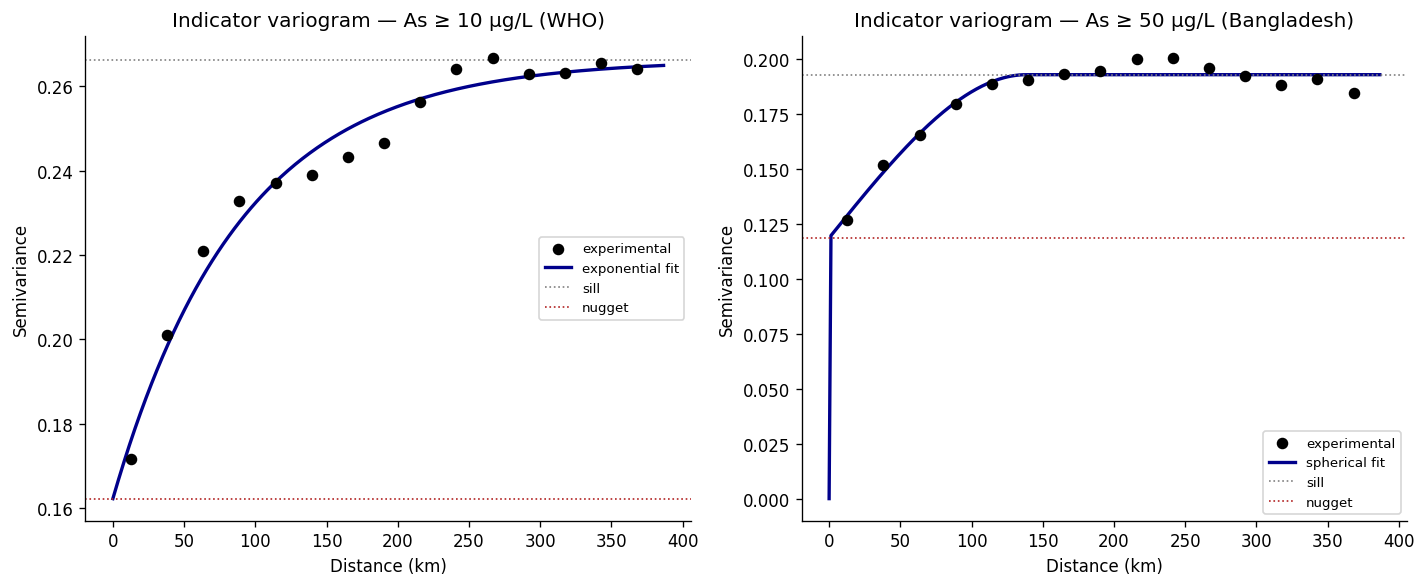

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (label, thr) in zip(axes, THRESHOLDS.items()):
    m = models[thr]
    lags, gamma = m["lags"], m["gamma"]
    nugget, psill, rng = m["params"]
    hh = np.linspace(0, lags.max() * 1.05, 300)
    fit = _VGM_MODELS[m["model"]](hh, nugget, psill, rng)

    ax.scatter(lags / 1000, gamma, c="black", s=35, zorder=3, label="experimental")
    ax.plot(hh / 1000, fit, color="darkblue", lw=2, label=f"{m['model']} fit")
    ax.axhline(nugget + psill, color="grey", ls=":", lw=1, label="sill")
    ax.axhline(nugget, color="firebrick", ls=":", lw=1, label="nugget")
    ax.set_title(f"Indicator variogram \u2014 As \u2265 {thr} \u00b5g/L ({label})")
    ax.set_xlabel("Distance (km)")
    ax.set_ylabel("Semivariance")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 9. Cross-Validation

Following the R `gstat::krige.cv(..., nfold = 5)` workflow, we use **5-fold cross-validation**: each fold is held out, indicator kriging is refit on the training folds, and P(indicator = 1) is predicted at held-out locations. Points are coloured **green** when the indicator is 0 (below threshold) and **red** when 1 (above); symbol size is proportional to predicted probability.


In [12]:
from sklearn.model_selection import KFold

def kfold_cv_indicator(coords, values, threshold, model, n_splits=5, seed=42):
    """5-fold CV for indicator kriging (matches gstat krige.cv, nfold = 5)."""
    coords = np.asarray(coords, float)
    values = np.asarray(values, float)
    pred = np.zeros(len(values))
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for train_idx, test_idx in kf.split(coords):
        ik = IndicatorKriging(cov_model=model["model"], max_neighbors=NMAX)
        ik.fit(coords[train_idx], values[train_idx])
        pred[test_idx] = ik.predict(coords[test_idx], threshold,
                                    {threshold: model["params"]})[threshold]
    return pred

cv_pred_10 = kfold_cv_indicator(coords, As, 10, models[10])
cv_pred_50 = kfold_cv_indicator(coords, As, 50, models[50])

for thr, pred in [(10, cv_pred_10), (50, cv_pred_50)]:
    obs = (As >= thr).astype(float)
    brier = np.mean((pred - obs) ** 2)
    print(f"As \u2265 {thr} \u00b5g/L: Brier score = {brier:.4f} | "
          f"pred range [{pred.min():.3f}, {pred.max():.3f}]")


As ≥ 10 µg/L: Brier score = 0.1500 | pred range [0.000, 1.000]
As ≥ 50 µg/L: Brier score = 0.1128 | pred range [0.000, 0.976]


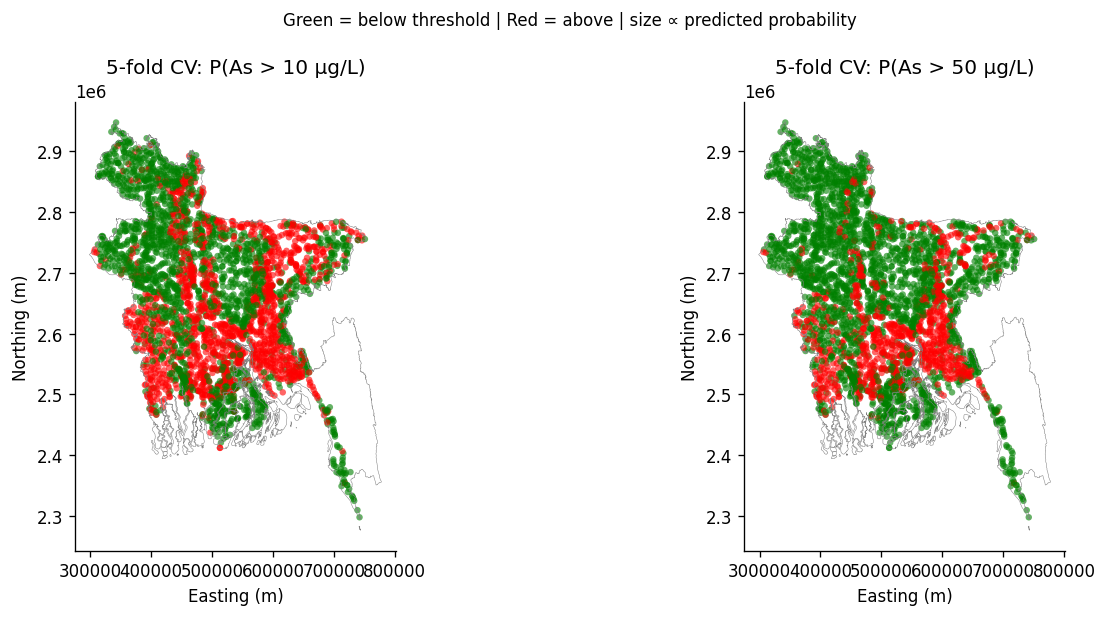

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, obs, title in zip(
    axes,
    [cv_pred_10, cv_pred_50],
    [mf.ik_10.values, mf.ik_50.values],
    ["5-fold CV: P(As > 10 µg/L)", "5-fold CV: P(As > 50 µg/L)"],
):
    colors = np.where(obs == 1, "red", "green")
    sizes = 10 + 80 * pred
    ax.scatter(mf.x, mf.y, c=colors, s=15, alpha=0.6, edgecolors="none")
    bd.boundary.plot(ax=ax, color="grey", linewidth=0.3)
    ax.set_title(title)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")
fig.suptitle("Green = below threshold | Red = above | size ∝ predicted probability", y=1.02, fontsize=10)
plt.tight_layout()
plt.show()


## 10. Indicator Kriging on the Prediction Grid

We krige each indicator onto the national prediction grid (`bd_grid.csv`). Predicted probabilities are clipped to [0, 1].


In [14]:
# Indicator kriging on the national prediction grid (bd_grid.csv) using
# the fitted per-threshold variogram models. max_neighbors = NMAX is the
# direct analogue of the R call krige(..., nmax = 50): unlike PyKrige's
# global OrdinaryKriging.execute(), IndicatorKriging supports a moving
# search neighbourhood, so we no longer have to krige with all points.
grid_coords = grid[["x", "y"]].values
grid_out = grid.copy()

for thr in THRESHOLDS.values():
    ik = IndicatorKriging(cov_model=models[thr]["model"], max_neighbors=NMAX)
    ik.fit(coords, As)
    prob = ik.predict(grid_coords, thr, {thr: models[thr]["params"]})[thr]
    grid_out[f"p_as_gt_{thr}"] = prob            # P(As >= threshold) -> UNSAFE
    grid_out[f"p_as_le_{thr}"] = 1.0 - prob      # P(As <  threshold) -> SAFE

print("Summary of P(As \u2265 10 \u00b5g/L)  [WHO]:\n",
      grid_out["p_as_gt_10"].describe().round(3).to_string())
print()
print("Summary of P(As \u2265 50 \u00b5g/L)  [Bangladesh]:\n",
      grid_out["p_as_gt_50"].describe().round(3).to_string())


Summary of P(As ≥ 10 µg/L)  [WHO]:
 count    5339.000
mean        0.401
std         0.298
min         0.000
25%         0.105
50%         0.366
75%         0.666
max         1.000

Summary of P(As ≥ 50 µg/L)  [Bangladesh]:
 count    5339.000
mean        0.229
std         0.250
min         0.000
25%         0.022
50%         0.129
75%         0.365
max         0.958


In [15]:
grid_out.head(10)


,ID,x,y,p_as_gt_10,p_as_le_10,p_as_gt_50,p_as_le_50
0,1,336021.659,2944492.72,0.022456,0.977544,0.0,1.0
1,2,341021.659,2944492.72,0.020187,0.979813,0.0,1.0
2,3,336021.659,2939492.72,0.024947,0.975053,0.0,1.0
3,4,341021.659,2939492.72,0.020975,0.979025,0.0,1.0
4,5,346021.659,2939492.72,0.020291,0.979709,0.0,1.0
5,6,336021.659,2934492.72,0.025358,0.974642,0.0,1.0
6,7,341021.659,2934492.72,0.024775,0.975225,0.0,1.0
7,8,346021.659,2934492.72,0.021761,0.978239,0.0,1.0
8,9,351021.659,2934492.72,0.023320,0.976680,0.0,1.0
9,10,336021.659,2929492.72,0.025777,0.974223,0.0,1.0


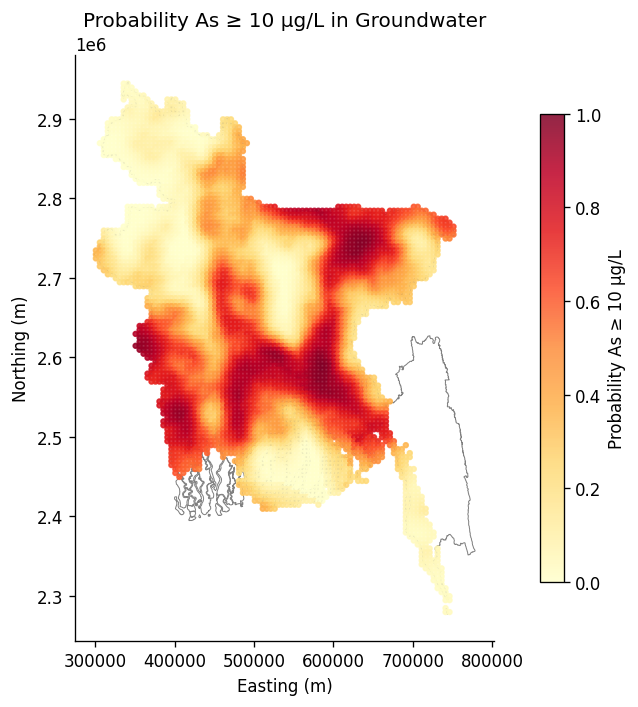

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))

bd.boundary.plot(ax=ax, color="grey", linewidth=0.6, zorder=1)
sc = ax.scatter(
    grid_out.x, grid_out.y,
    c=grid_out.p_as_gt_10,
    s=8,
    cmap="YlOrRd",
    #vmin=0, vmax=1,   # Probability values between 0 and 1
    alpha=0.85,
    zorder=2
)
plt.colorbar(sc, ax=ax, label="Probability As ≥ 10 µg/L", shrink=0.8)
ax.set_title("Probability As ≥ 10 µg/L in Groundwater")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.show()

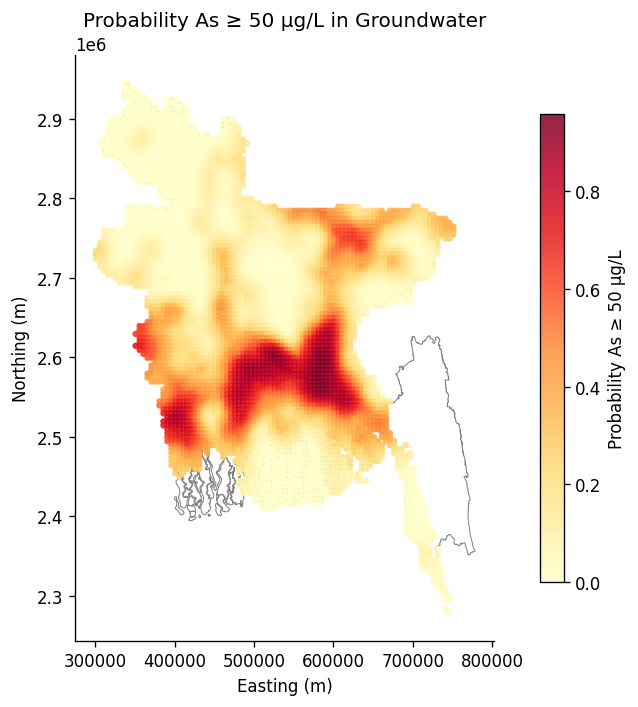

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))

bd.boundary.plot(ax=ax, color="grey", linewidth=0.6, zorder=1)
sc = ax.scatter(
    grid_out.x, grid_out.y,
    c=grid_out.p_as_gt_50,
    s=8,
    cmap="YlOrRd",
    #vmin=0, vmax=1,   # Probability values between 0 and 1
    alpha=0.85,
    zorder=2
)
plt.colorbar(sc, ax=ax, label="Probability As ≥ 50 µg/L", shrink=0.8)
ax.set_title("Probability As ≥ 50 µg/L in Groundwater")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.show()

## 11. Probability Maps

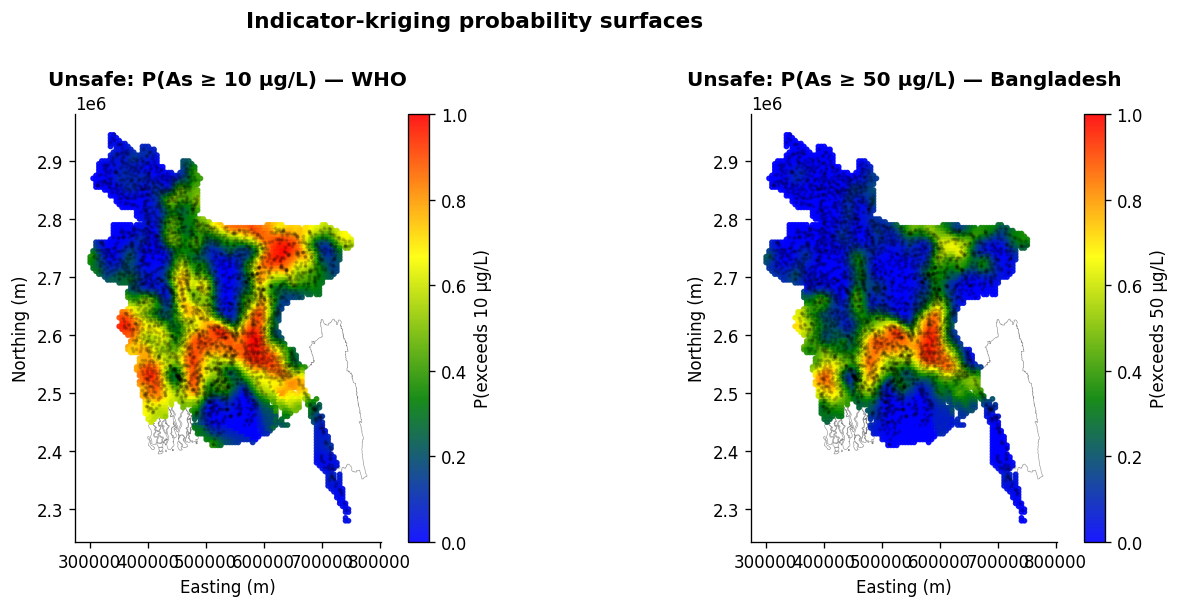

In [18]:
from matplotlib.colors import LinearSegmentedColormap

# Blue -> green -> yellow -> red (R's colorRampPalette equivalent).
risk_cmap = LinearSegmentedColormap.from_list("risk", ["blue", "green", "yellow", "red"], N=255)
safe_cmap = risk_cmap.reversed()   # high P(safe) -> blue; red still flags danger in both columns

def probability_map(ax, value_col, title, cbar_label, cmap):
    bd.boundary.plot(ax=ax, color="grey", linewidth=0.3, zorder=1)
    pts = ax.scatter(grid_out.x, grid_out.y, c=grid_out[value_col],
                     cmap=cmap, vmin=0, vmax=1, s=6, alpha=0.9, zorder=2)
    ax.scatter(mf.x, mf.y, c="black", s=2, alpha=0.15, zorder=3)   # sample locations
    cb = plt.colorbar(pts, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(cbar_label, fontsize=10)
    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# WHO guideline, 10 µg/L
probability_map(axes[0], "p_as_gt_10",
                "Unsafe: P(As \u2265 10 \u00b5g/L) \u2014 WHO",
                "P(exceeds 10 \u00b5g/L)", risk_cmap)
# Bangladesh national standard, 50 µg/L
probability_map(axes[1], "p_as_gt_50",
                "Unsafe: P(As \u2265 50 \u00b5g/L) \u2014 Bangladesh",
                "P(exceeds 50 \u00b5g/L)", risk_cmap)



fig.suptitle("Indicator-kriging probability surfaces",
             y=1.005, fontsize=13, weight="bold")
plt.tight_layout()
plt.show()


## 12. District-Level Risk Summary

The boundary shapefile labels are sparse, so we summarise risk using the **DISTRICT** field from the BGS borehole survey. For each district we report the fraction of sampled wells exceeding each threshold and the mean IK probability at sample locations (by joining each borehole to its nearest grid cell).


In [19]:
# Map each borehole to nearest prediction-grid cell
from scipy.spatial import cKDTree

tree = cKDTree(grid_out[["x", "y"]].values)
_, nn_idx = tree.query(mf[["x", "y"]].values)
mf_out = mf.copy()
mf_out["p_as_gt_10"] = grid_out.iloc[nn_idx]["p_as_gt_10"].values
mf_out["p_as_gt_50"] = grid_out.iloc[nn_idx]["p_as_gt_50"].values

district_risk = (
    mf_out.groupby("DISTRICT")
    .agg(
        n_wells=("As", "size"),
        frac_gt_10=("ik_10", "mean"),
        frac_gt_50=("ik_50", "mean"),
        mean_p_gt_10=("p_as_gt_10", "mean"),
        mean_p_gt_50=("p_as_gt_50", "mean"),
        median_as=("As", "median"),
    )
    .sort_values("frac_gt_10", ascending=False)
)
print("Top 10 districts by sampled exceedance of WHO guideline (10 µg/L):")
print(district_risk.head(10).round(3).to_string())


Top 10 districts by sampled exceedance of WHO guideline (10 µg/L):
            n_wells  frac_gt_10  frac_gt_50  mean_p_gt_10  mean_p_gt_50  median_as
DISTRICT                                                                          
Chandpur         53       0.925       0.906         0.928         0.895     398.00
Meherpur         13       0.923       0.615         0.827         0.559      62.50
Munshiganj       45       0.911       0.822         0.825         0.752     167.00
Sunamganj        68       0.853       0.397         0.843         0.396      44.40
Noakhali         45       0.844       0.689         0.816         0.661     107.00
Gopalganj        40       0.825       0.775         0.824         0.763     145.00
Bagerhat         59       0.814       0.593         0.716         0.514     103.00
Chuadanga        32       0.812       0.406         0.782         0.438      44.95
Lakshmipur       31       0.806       0.581         0.745         0.595      82.60
Satkhira         56 

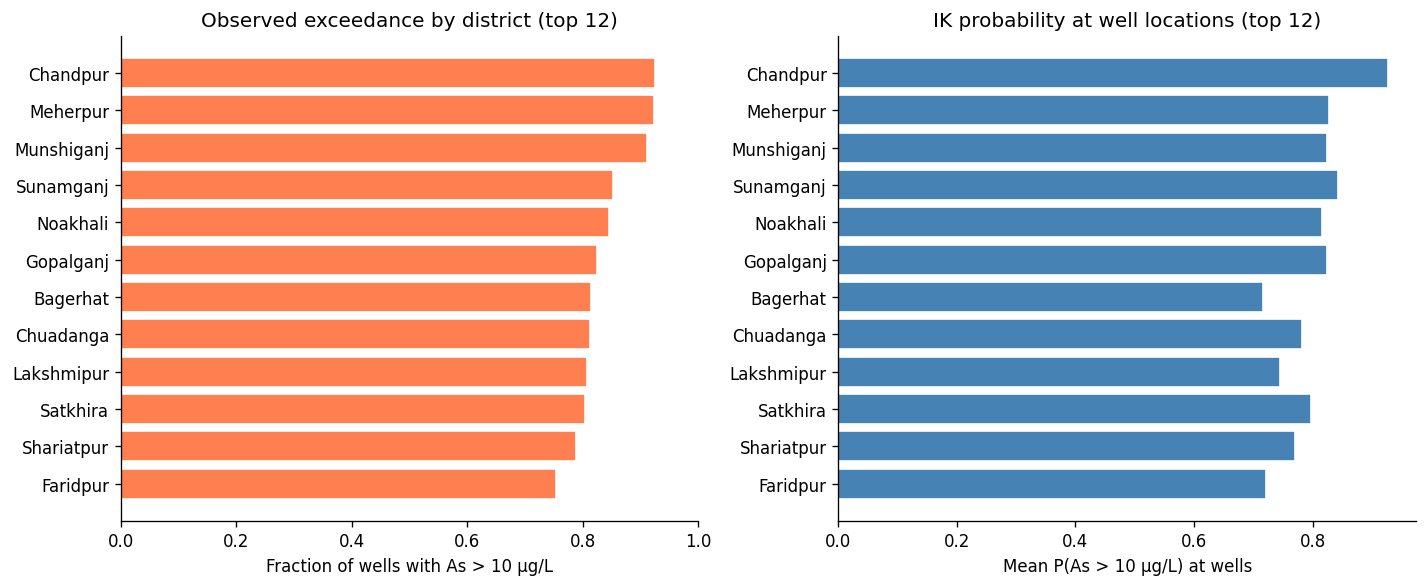

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

top = district_risk.head(12)
axes[0].barh(top.index[::-1], top.frac_gt_10[::-1], color="coral", edgecolor="white")
axes[0].set_xlabel("Fraction of wells with As > 10 µg/L")
axes[0].set_title("Observed exceedance by district (top 12)")
axes[0].set_xlim(0, 1)

axes[1].barh(top.index[::-1], top.mean_p_gt_10[::-1], color="steelblue", edgecolor="white")
axes[1].set_xlabel("Mean P(As > 10 µg/L) at wells")
axes[1].set_title("IK probability at well locations (top 12)")
plt.tight_layout()
plt.show()


## 13. Interpretation & Health Policy Context

**Key findings from indicator kriging:**

- IK maps show *where* groundwater is likely unsafe, not just where samples were taken — critical because borehole density is uneven.
- Each threshold is mapped as a **pair** of surfaces: the *unsafe* probability $P(As \ge t)$ and its complement, the *safe* probability $P(As < t)$.
- The 10 µg/L (WHO) surface is more extensive than the 50 µg/L (Bangladesh) surface, reflecting the stricter health guideline.
- Probabilities are spatially smooth but locally adjusted to nearby sample indicators.
- Cross-validation Brier scores quantify calibration; lower is better.

**Limitations:**
- Predictions use the custom `pygstat` `IndicatorKriging` with a moving neighbourhood of `NMAX = 50` points (the `nmax` analogue of the classic R `gstat::krige` workflow), rather than a global solver.
- IK assumes stationarity of the indicator semivariogram.
- Censored values at 0.25 µg/L affect indicators only near zero.
- E-type concentration estimates require multiple thresholds and CDF reconstruction (Goovaerts AUTO-IK).

**References:**
- Goovaerts P. (2009). AUTO-IK: a geostatistical program for indicator kriging. *Environ Sci Technol*.
- BGS Bangladesh arsenic survey: [bgs.ac.uk groundwater health data](http://www.bgs.ac.uk/research/groundwater/health/arsenic/Bangladesh/data.html)


## 14. Knowledge Check
1. Why is indicator kriging preferred over ordinary kriging on log-transformed arsenic for mapping regulatory exceedance?
2. What does a predicted probability of 0.7 at an unmonitored grid cell mean for a household relying on a local tube well?
3. How would you test whether the exponential variogram model is adequate for the 50 µg/L indicator?
4. If the Bangladesh government wanted to prioritise well testing, how would you use the P(As > 50 µg/L) map to rank districts?
5. Extend the analysis: add a third threshold (e.g., 200 µg/L) and compare spatial patterns of severe poisoning risk.


***
**Next → NB-08: Capstone — Spatial Health Inequity Atlas** (or continue to advanced spatial ML in NB-09)
